#### [ORBIT: Order-Aware Regression model with Basis, Interactions & Trends](https://medium.com/@jceweaver/introduction-to-orbit-order-aware-regression-model-with-basis-interactions-trends-8abbe8c56fe2)

In [1]:
!pip install -q astra-ai shap

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

##### ============================================================
##### ORBIT: Single Regressor Example
##### ============================================================

RMSE=2.1229, MAE=1.6526, R2=0.8002, 90% PI coverage=0.900


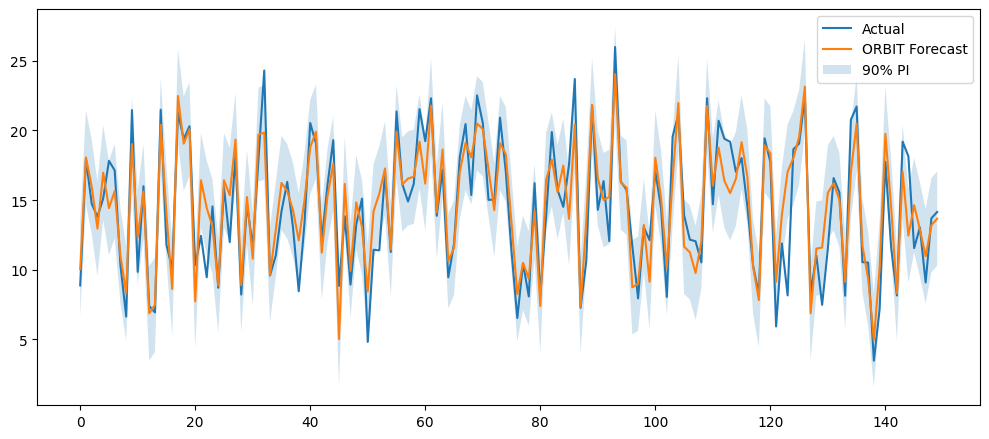

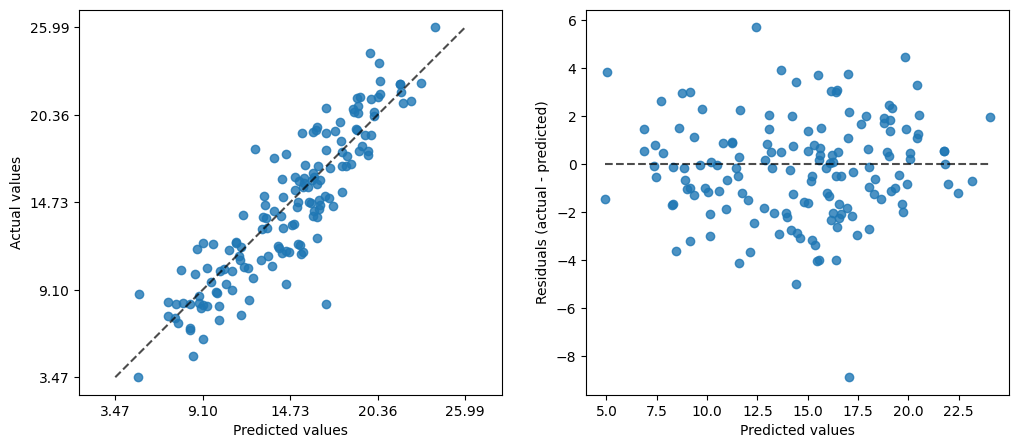

PermutationExplainer explainer: 151it [09:29,  3.80s/it]


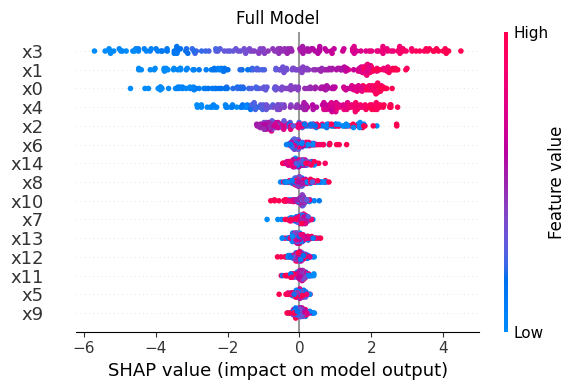

In [3]:
from astra_ai import ORBITRegressor
from sklearn.datasets import make_friedman1
from sklearn.metrics import mean_absolute_error, r2_score, PredictionErrorDisplay
import numpy as np, matplotlib.pyplot as plt, shap

# Prepare data
X_df, y_df = make_friedman1(n_samples=4000, n_features=15, noise=1.0, random_state=42)
n_test = 150
Xtr, Xte = X_df[:-n_test], X_df[-n_test:]
ytr, yte = y_df[:-n_test], y_df[-n_test:]

# Initialise single ORBIT model
orbit = ORBITRegressor(
    n_keep_dims=22,
    n_knots=7,
    use_wavelet=True,
    include_splines=True,
    top_pairs=48,
    triple_max=4,
    rff_dims=200,
    rff_gamma="auto",
    n_atoms=64,
    ridge_alpha=1.0,
    pre_screen_frac=0.25,
    pre_screen_cap=800,
    screen_frac=0.6,
    screen_cap=900,
    bank_dropout=0.10,
    huber_refit=True,
    huber_iters=3,
    stack_mode="ridge",
    stack_ridge_alpha=1e-3,
    val_size=0.20,
    random_state=42,
)

# Fit model and predict
orbit.fit(Xtr, ytr)
yhat, PI = orbit.predict(Xte, return_interval=True)

# Evaluate
rmse = np.sqrt(np.mean((yte - yhat)**2))
mae = mean_absolute_error(yte, yhat)
r2 = r2_score(yte, yhat)
coverage = np.mean((yte >= PI[:, 0]) & (yte <= PI[:, 1]))

print(f"RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, 90% PI coverage={coverage:.3f}")

# Plot forecasts and prediction intervals
plt.figure(figsize=(10, 4.5))
plt.plot(yte, lw=1.5, label="Actual")
plt.plot(yhat, lw=1.5, label="ORBIT Forecast")
plt.fill_between(np.arange(len(yte)), PI[:, 0], PI[:, 1], alpha=0.2, label="90% PI")
plt.legend()
plt.tight_layout()
plt.show()

# Diagnostic plots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
PredictionErrorDisplay.from_estimator(orbit, Xte, yte, kind="actual_vs_predicted", ax=axs[0])
PredictionErrorDisplay.from_estimator(orbit, Xte, yte, kind="residual_vs_predicted", ax=axs[1])
plt.show()

# SHAP-based explanations
from astra_ai import shap_callables, beeswarm_one, perm_importance_callable
f_full, f_lin, f_nl = shap_callables(orbit)

mask = shap.maskers.Independent(shap.sample(Xtr, 1000))
expl_full = shap.Explainer(f_full, mask, feature_names=[f"x{i}" for i in range(X_df.shape[1])])
s_full = expl_full(Xte)
beeswarm_one(s_full, "Full Model")

##### ============================================================
##### ORBIT: Bagged Regressor Example
##### ============================================================

RMSE=1.8336, MAE=1.4403, R2=0.8509, 90% PI coverage=0.920


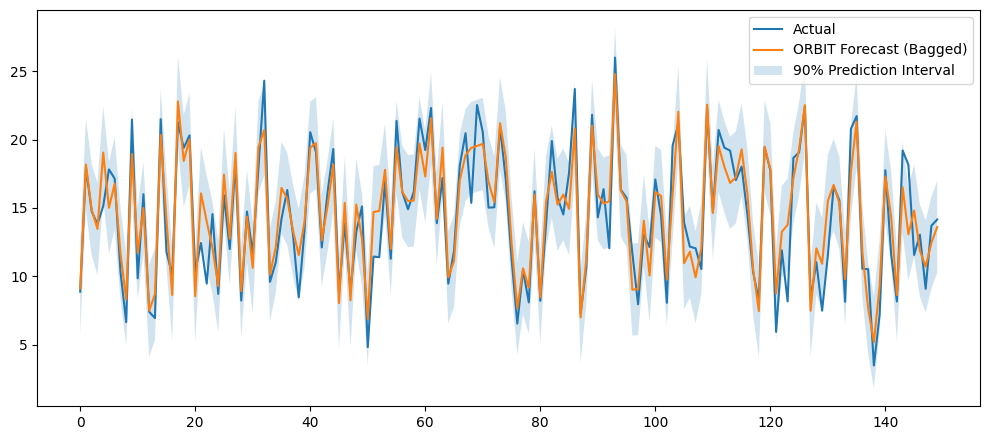

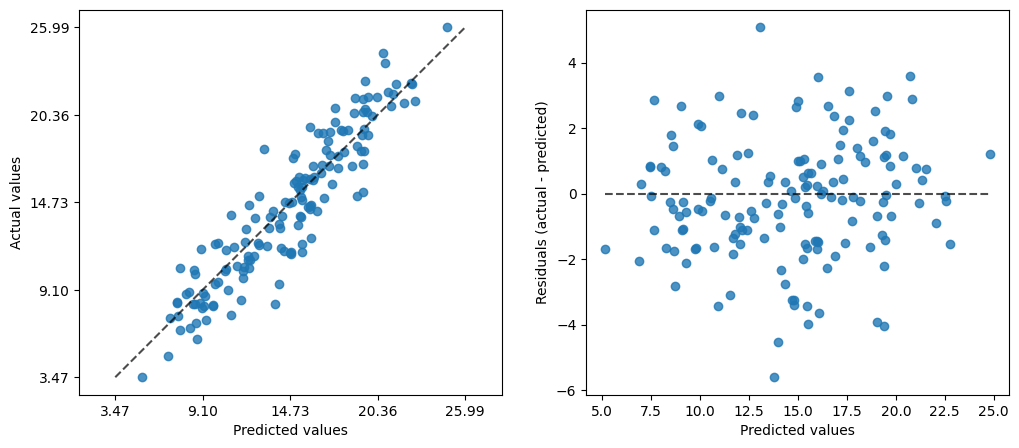

PermutationExplainer explainer: 151it [26:59, 10.87s/it]


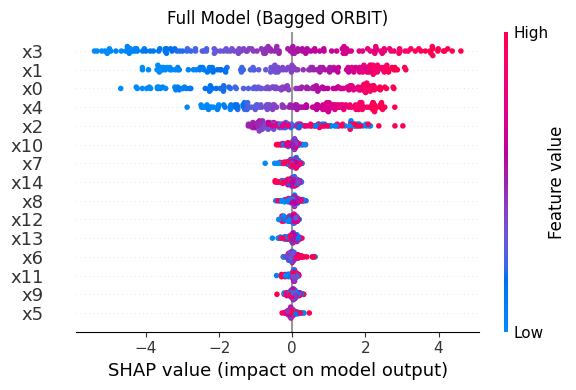

In [4]:
from astra_ai import ORBITBaggedRegressor
from sklearn.datasets import make_friedman1
from sklearn.metrics import mean_absolute_error, r2_score, PredictionErrorDisplay
import numpy as np
import matplotlib.pyplot as plt
import shap

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
X_df, y_df = make_friedman1(n_samples=4000, n_features=15, noise=1.0, random_state=42)
n_test = 150
Xtr, Xte = X_df[:-n_test], X_df[-n_test:]
ytr, yte = y_df[:-n_test], y_df[-n_test:]

# ------------------------------------------------------------
# Initialise bagged ORBIT model
# ------------------------------------------------------------
orbit = ORBITBaggedRegressor(
    n_estimators=3,          # number of base models to average
    random_state=42,         # for reproducibility
    base_kwargs=dict(
        n_keep_dims=22,
        n_knots=7,
        use_wavelet=True,
        include_splines=True,
        top_pairs=48,
        triple_max=4,
        rff_dims=200,
        rff_gamma="auto",
        n_atoms=64,
        ridge_alpha=1.0,
        pre_screen_frac=0.25,
        pre_screen_cap=800,
        screen_frac=0.6,
        screen_cap=900,
        bank_dropout=0.10,
        huber_refit=True,
        huber_iters=3,
        stack_mode="ridge",
        stack_ridge_alpha=1e-3,
        val_size=0.20,
    )
)

# ------------------------------------------------------------
# Fit model and predict
# ------------------------------------------------------------
orbit.fit(Xtr, ytr)
yhat, PI = orbit.predict(Xte, return_interval=True)

# ------------------------------------------------------------
# Evaluate performance and coverage
# ------------------------------------------------------------
rmse = np.sqrt(np.mean((yte - yhat)**2))
mae = mean_absolute_error(yte, yhat)
r2 = r2_score(yte, yhat)
coverage = np.mean((yte >= PI[:, 0]) & (yte <= PI[:, 1]))

print(f"RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}, 90% PI coverage={coverage:.3f}")

# ------------------------------------------------------------
# Plot forecasts and prediction intervals
# ------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
plt.plot(yte, lw=1.5, label="Actual")
plt.plot(yhat, lw=1.5, label="ORBIT Forecast (Bagged)")
plt.fill_between(np.arange(len(yte)), PI[:, 0], PI[:, 1],
                 alpha=0.2, label="90% Prediction Interval")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Diagnostic plots
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
PredictionErrorDisplay.from_estimator(orbit, Xte, yte, kind="actual_vs_predicted", ax=axs[0])
PredictionErrorDisplay.from_estimator(orbit, Xte, yte, kind="residual_vs_predicted", ax=axs[1])
plt.show()

# ------------------------------------------------------------
# SHAP-based explanations
# ------------------------------------------------------------
from astra_ai import shap_callables, beeswarm_one

# Build SHAP-compatible callables
f_full, f_lin, f_nl = shap_callables(orbit)
mask = shap.maskers.Independent(shap.sample(Xtr, 1000))
expl_full = shap.Explainer(f_full, mask, feature_names=[f"x{i}" for i in range(X_df.shape[1])])
s_full = expl_full(Xte)
beeswarm_one(s_full, "Full Model (Bagged ORBIT)")